In [1]:
# I start by loading the dataset and checking its basic structure.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

file_path = r"C:\Users\DELL\Desktop\creditcard.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

display(df.head())
display(df.tail())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset loaded successfully.
Shape of dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0000,-11.8811,10.0718,-9.8348,-2.0667,-5.3645,-2.6068,-4.9182,7.3053,1.9144,4.3562,-1.5931,2.7119,-0.6893,4.6269,-0.9245,1.1076,1.9917,0.5106,-0.6829,1.4758,0.2135,0.1119,1.0145,-0.5093,1.4368,0.2500,0.9437,0.8237,0.7700,0
284803,172787.0000,-0.7328,-0.0551,2.0350,-0.7386,0.8682,1.0584,0.0243,0.2949,0.5848,-0.9759,-0.1502,0.9158,1.2148,-0.6751,1.1649,-0.7118,-0.0257,-1.2212,-1.5456,0.0596,0.2142,0.9244,0.0125,-1.0162,-0.6066,-0.3953,0.0685,-0.0535,24.7900,0
284804,172788.0000,1.9196,-0.3013,-3.2496,-0.5578,2.6305,3.0313,-0.2968,0.7084,0.4325,-0.4848,0.4116,0.0631,-0.1837,-0.5106,1.3293,0.1407,0.3135,0.3957,-0.5773,0.0014,0.2320,0.5782,-0.0375,0.6401,0.2657,-0.0874,0.0045,-0.0266,67.8800,0
284805,172788.0000,-0.2404,0.5305,0.7025,0.6898,-0.3780,0.6237,-0.6862,0.6791,0.3921,-0.3991,-1.9338,-0.9629,-1.0421,0.4496,1.9626,-0.6086,0.5099,1.1140,2.8978,0.1274,0.2652,0.8000,-0.1633,0.1232,-0.5692,0.5467,0.1088,0.1045,10.0000,0
284806,172792.0000,-0.5334,-0.1897,0.7033,-0.5063,-0.0125,-0.6496,1.5770,-0.4147,0.4862,-0.9154,-1.0405,-0.0315,-0.1881,-0.0843,0.0413,-0.3026,-0.6604,0.1674,-0.2561,0.3829,0.2611,0.6431,0.3768,0.0088,-0.4736,-0.8183,-0.0024,0.0136,217.0000,0



Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null 

In [2]:
# I check data quality and confirm how imbalanced the fraud class is.

print("Shape before duplicate check:", df.shape)

missing_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(4)
})

print("\nMissing value summary:")
display(missing_summary[missing_summary["missing_values"] > 0])

if missing_summary["missing_values"].sum() == 0:
    print("No missing values found in the dataset.")

duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("\nDuplicate row check:")
print("Duplicate rows:", duplicate_count)
print("Duplicate percentage: {:.4f}%".format(duplicate_percentage))

class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Class label": ["Legitimate transaction", "Fraudulent transaction"],
    "Count": class_counts.values,
    "Percentage": class_percentages.round(4).values
})

print("\nTarget class distribution:")
display(class_summary)

amount_summary = df.groupby("Class")["Amount"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).round(4)

amount_summary.index = ["Legitimate transaction", "Fraudulent transaction"]

print("\nTransaction amount summary by class:")
display(amount_summary)

time_summary = df["Time"].describe().to_frame(name="Time").round(4)
amount_overall_summary = df["Amount"].describe().to_frame(name="Amount").round(4)

print("\nOverall Time summary:")
display(time_summary)

print("\nOverall Amount summary:")
display(amount_overall_summary)

Shape before duplicate check: (284807, 31)

Missing value summary:


,missing_values,missing_percentage


No missing values found in the dataset.

Duplicate row check:
Duplicate rows: 1081
Duplicate percentage: 0.3796%

Target class distribution:


,Class label,Count,Percentage
0,Legitimate transaction,284315,99.8273
1,Fraudulent transaction,492,0.1727



Transaction amount summary by class:


,count,mean,median,std,min,max
Legitimate transaction,284315,88.2910,22.0000,250.1051,0.0000,25691.1600
Fraudulent transaction,492,122.2113,9.2500,256.6833,0.0000,2125.8700



Overall Time summary:


,Time
count,284807.0000
mean,94813.8596
std,47488.1460
min,0.0000
25%,54201.5000
50%,84692.0000
75%,139320.5000
max,172792.0000



Overall Amount summary:


,Amount
count,284807.0000
mean,88.3496
std,250.1201
min,0.0000
25%,5.6000
50%,22.0000
75%,77.1650
max,25691.1600


Original shape: (284807, 31)
Shape after removing duplicates: (283726, 31)
Rows removed: 1081

Class distribution after duplicate removal:


,Class label,Count,Percentage
0,Legitimate transaction,283253,99.8333
1,Fraudulent transaction,473,0.1667


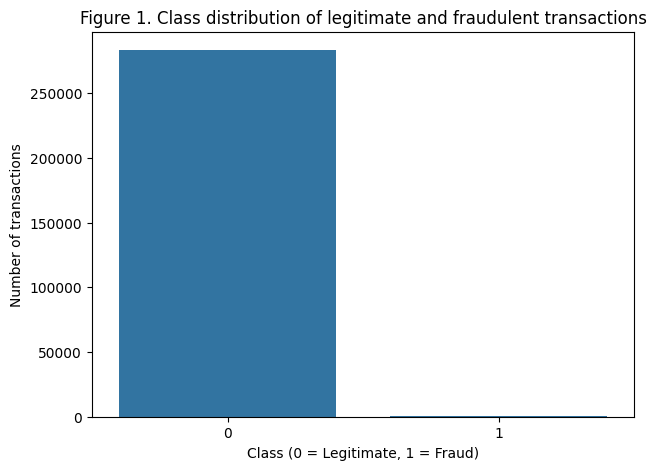

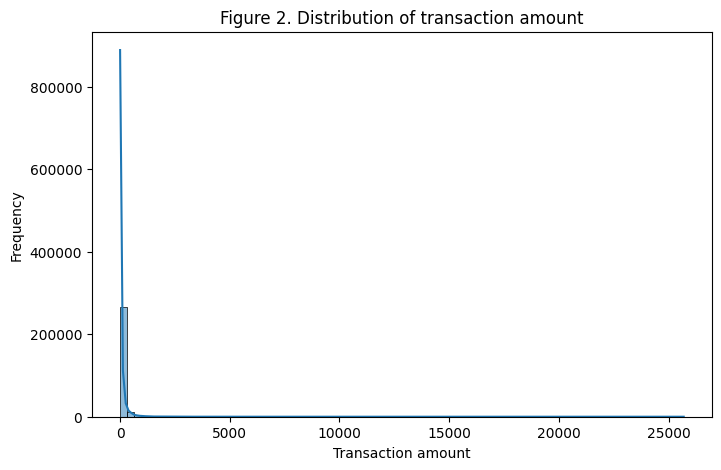

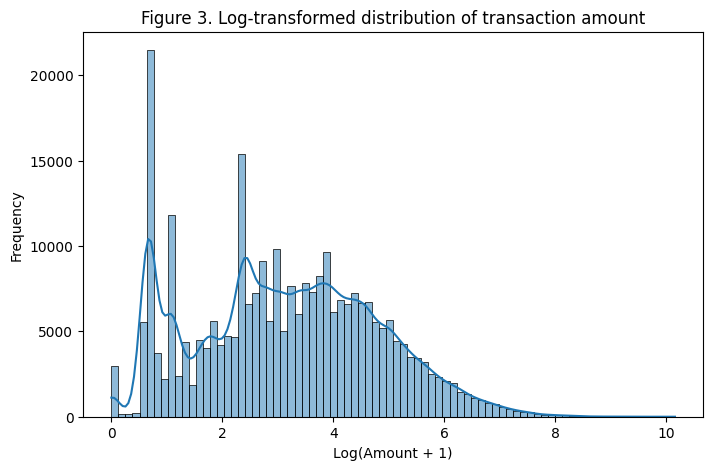

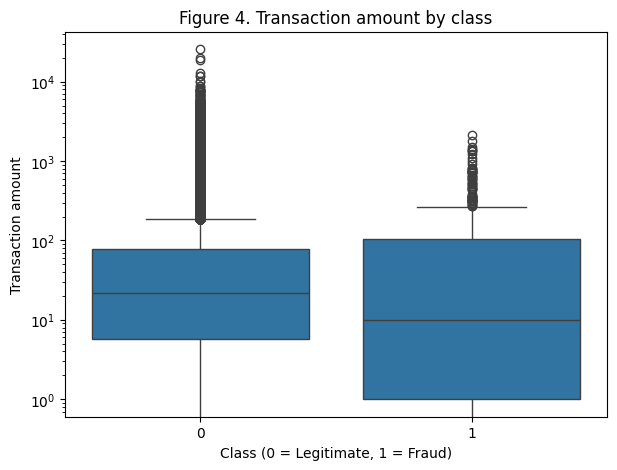

In [3]:
# I create a cleaned copy and visualise the main class and amount patterns.

df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("Shape after removing duplicates:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

clean_class_counts = df_clean["Class"].value_counts().sort_index()
clean_class_percentages = df_clean["Class"].value_counts(normalize=True).sort_index() * 100

clean_class_summary = pd.DataFrame({
    "Class label": ["Legitimate transaction", "Fraudulent transaction"],
    "Count": clean_class_counts.values,
    "Percentage": clean_class_percentages.round(4).values
})

print("\nClass distribution after duplicate removal:")
display(clean_class_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x="Class")
plt.title("Figure 1. Class distribution of legitimate and fraudulent transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of transactions")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Amount"], bins=80, kde=True)
plt.title("Figure 2. Distribution of transaction amount")
plt.xlabel("Transaction amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df_clean["Amount"]), bins=80, kde=True)
plt.title("Figure 3. Log-transformed distribution of transaction amount")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="Class", y="Amount")
plt.title("Figure 4. Transaction amount by class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction amount")
plt.yscale("log")
plt.show()

Hourly transaction summary:


,Legitimate,Fraud,Fraud_rate_percentage
Hour,,,
0.0000,7641,6,0.0785
1.0000,4198,10,0.2376
2.0000,3260,48,1.4510
3.0000,3470,17,0.4875
4.0000,2181,23,1.0436
5.0000,2977,11,0.3681
6.0000,4073,9,0.2205
7.0000,7210,23,0.3180
8.0000,10223,9,0.0880


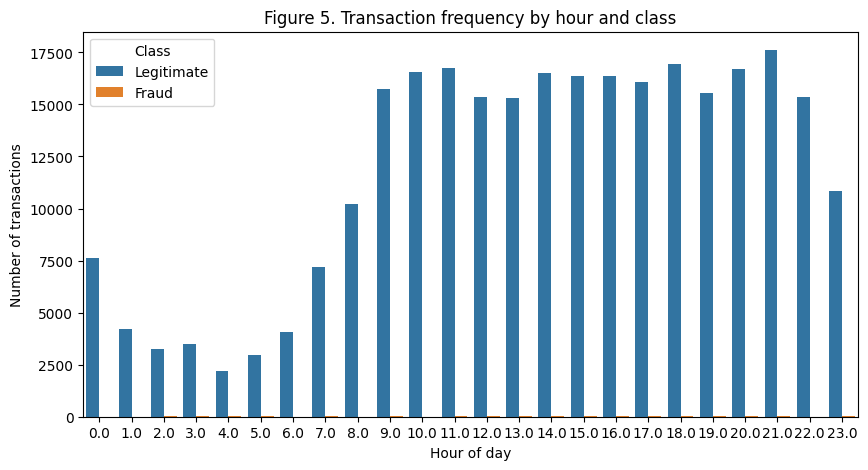

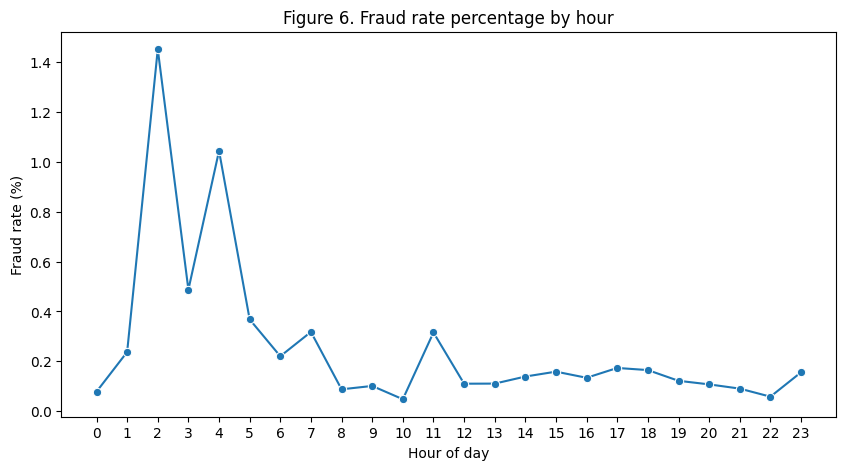

Top correlations with fraud class:


,Correlation with Class
V17,-0.3135
V14,-0.2934
V12,-0.2507
V10,-0.2070
V16,-0.1872
V3,-0.1823
V7,-0.1723
V11,0.1491
V4,0.1293
V18,-0.1053


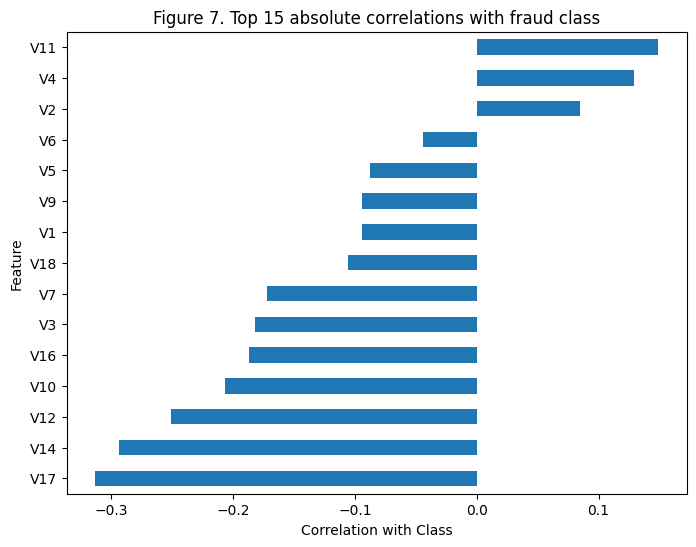

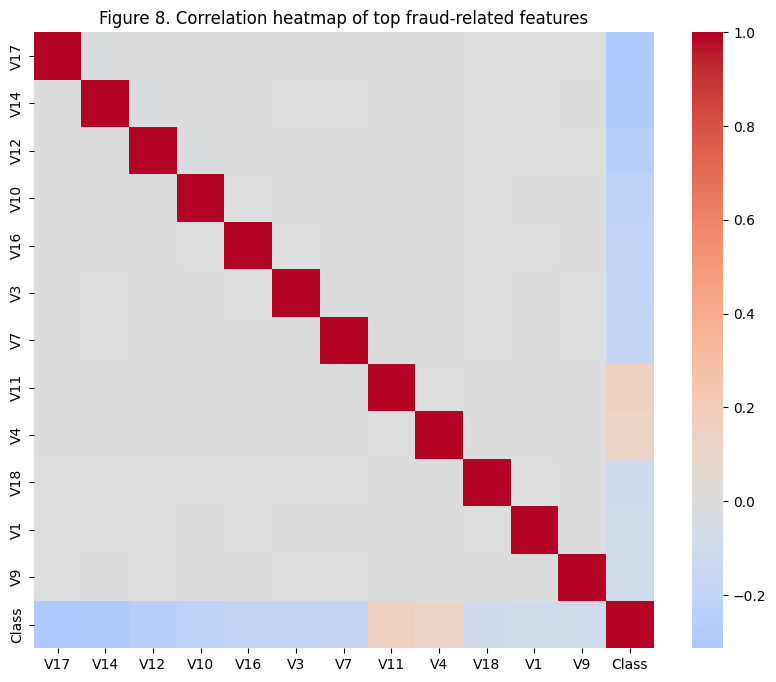

In [4]:
# I check whether transaction timing and feature correlations show useful fraud patterns.

df_clean["Hour"] = (df_clean["Time"] // 3600) % 24

hourly_class = (
    df_clean.groupby(["Hour", "Class"])
    .size()
    .reset_index(name="Count")
)

hourly_pivot = hourly_class.pivot(index="Hour", columns="Class", values="Count").fillna(0)
hourly_pivot.columns = ["Legitimate", "Fraud"]

hourly_pivot["Fraud_rate_percentage"] = (
    hourly_pivot["Fraud"] / (hourly_pivot["Legitimate"] + hourly_pivot["Fraud"]) * 100
).round(4)

print("Hourly transaction summary:")
display(hourly_pivot.head(24))

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x="Hour", hue="Class")
plt.title("Figure 5. Transaction frequency by hour and class")
plt.xlabel("Hour of day")
plt.ylabel("Number of transactions")
plt.legend(title="Class", labels=["Legitimate", "Fraud"])
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_pivot, x=hourly_pivot.index, y="Fraud_rate_percentage", marker="o")
plt.title("Figure 6. Fraud rate percentage by hour")
plt.xlabel("Hour of day")
plt.ylabel("Fraud rate (%)")
plt.xticks(range(0, 24))
plt.show()

corr_with_class = (
    df_clean.drop(columns=["Hour"])
    .corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

print("Top correlations with fraud class:")
display(corr_with_class.head(15).to_frame(name="Correlation with Class"))

plt.figure(figsize=(8, 6))
corr_with_class.head(15).sort_values().plot(kind="barh")
plt.title("Figure 7. Top 15 absolute correlations with fraud class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")
plt.show()

selected_corr_features = corr_with_class.head(12).index.tolist() + ["Class"]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_clean[selected_corr_features].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Figure 8. Correlation heatmap of top fraud-related features")
plt.show()

In [5]:
# I prepare the modelling data without leaking information from the test set.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

train_dist = pd.DataFrame({
    "Class": ["Legitimate", "Fraud"],
    "Train count": y_train.value_counts().sort_index().values,
    "Train percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(4).values,
    "Test count": y_test.value_counts().sort_index().values,
    "Test percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(4).values
})

print("\nClass distribution after stratified train-test split:")
display(train_dist)

numeric_features = X.columns.tolist()

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("\nScaling completed.")
print("Training feature mean after scaling, first five columns:")
display(X_train_scaled[numeric_features].mean().head().round(4))

print("\nTraining feature standard deviation after scaling, first five columns:")
display(X_train_scaled[numeric_features].std().head().round(4))

Feature matrix shape: (283726, 31)
Target shape: (283726,)

Training set shape: (226980, 31)
Test set shape: (56746, 31)

Class distribution after stratified train-test split:


,Class,Train count,Train percentage,Test count,Test percentage
0,Legitimate,226602,99.8335,56651,99.8326
1,Fraud,378,0.1665,95,0.1674



Scaling completed.
Training feature mean after scaling, first five columns:


Time   -0.0000
V1      0.0000
V2     -0.0000
V3      0.0000
V4     -0.0000
dtype: float64


Training feature standard deviation after scaling, first five columns:


Time   1.0000
V1     1.0000
V2     1.0000
V3     1.0000
V4     1.0000
dtype: float64

In [7]:
# I train baseline models first, using the original imbalanced training data.

baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight=None,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight=None
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

def evaluate_model(model, X_train_data, y_train_data, X_test_data, y_test_data):
    model.fit(X_train_data, y_train_data)

    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_data)[:, 1]
    else:
        y_score = model.decision_function(X_test_data)

    results = {
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred, zero_division=0),
        "Recall": recall_score(y_test_data, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_data, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_data, y_score),
        "PR-AUC": average_precision_score(y_test_data, y_score)
    }

    return results, y_pred, y_score

baseline_results = []
baseline_predictions = {}
baseline_scores = {}

for name, model in baseline_models.items():
    print(f"Training {name}...")
    results, y_pred, y_score = evaluate_model(
        model,
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test
    )

    results["Model"] = name
    baseline_results.append(results)
    baseline_predictions[name] = y_pred
    baseline_scores[name] = y_score

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
].sort_values(by="F1-score", ascending=False)

print("\nBaseline model performance on untouched test set:")
display(baseline_results_df.round(4))

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

Baseline model performance on untouched test set:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
2,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9348,0.7990
3,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539,0.6234
1,Decision Tree,0.9990,0.7326,0.6632,0.6961,0.8314,0.4864
0,Logistic Regression,0.9991,0.8485,0.5895,0.6957,0.9562,0.6887


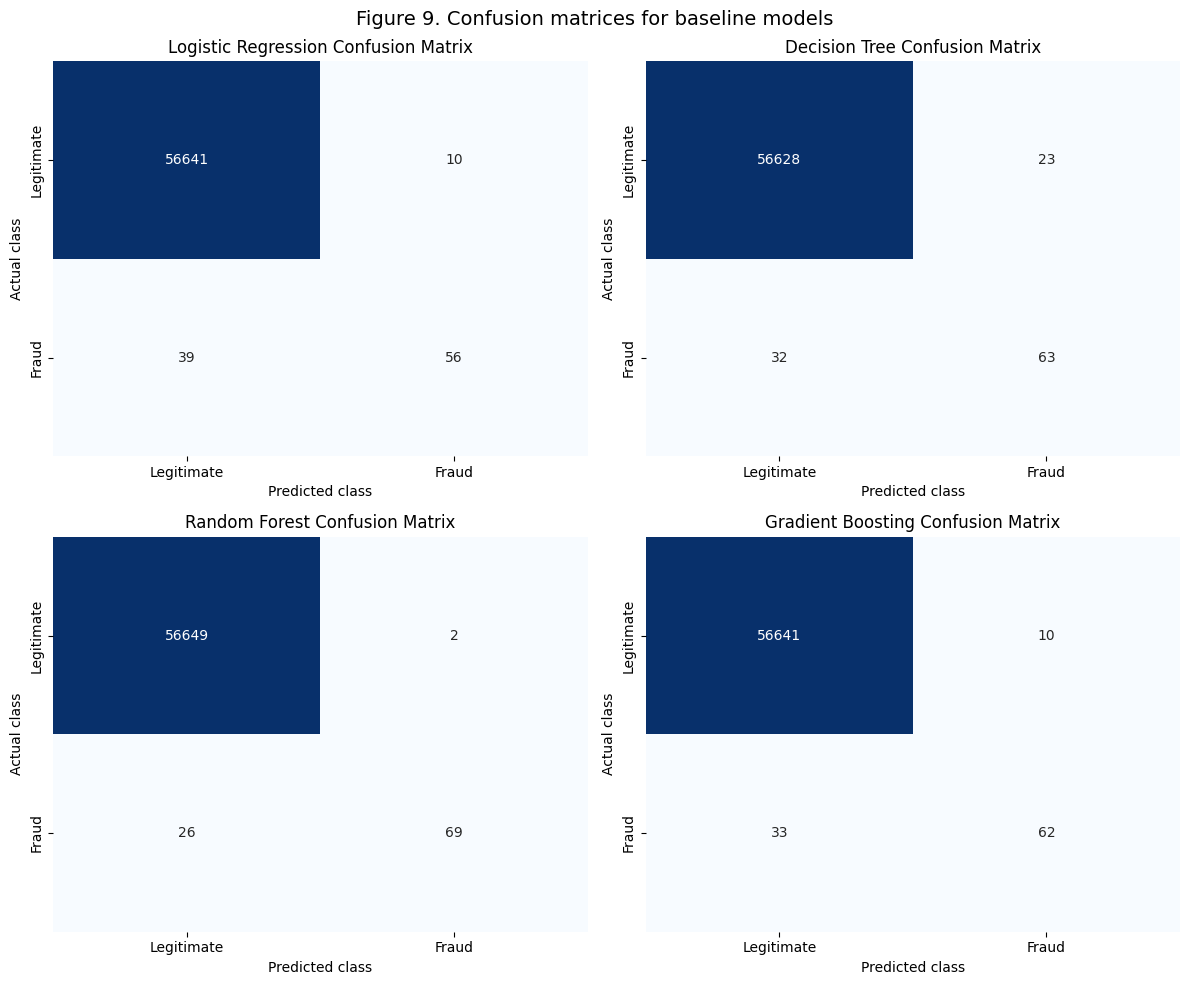

<Figure size 1000x500 with 0 Axes>

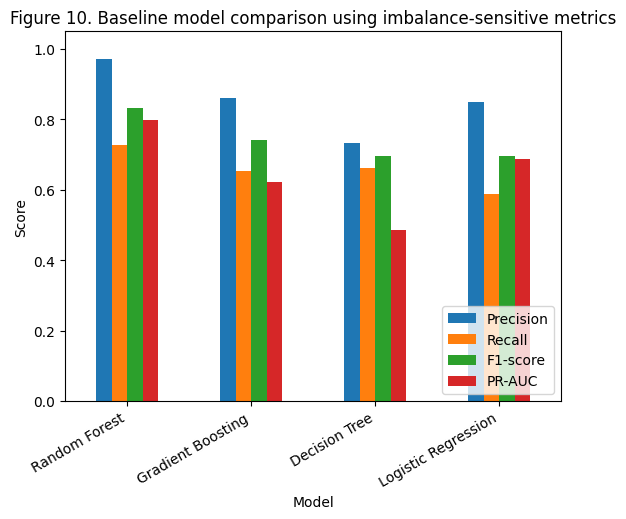

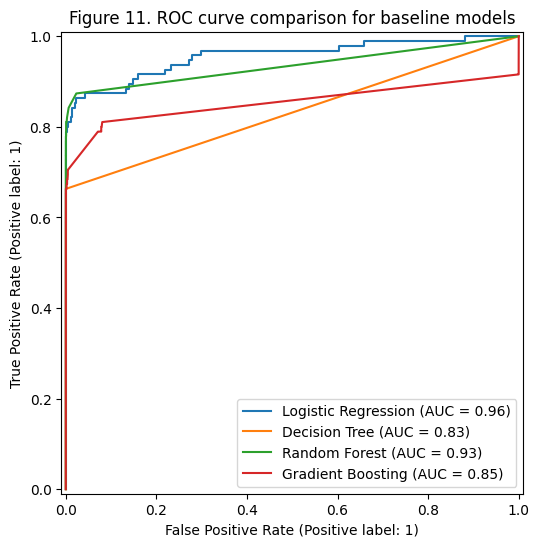

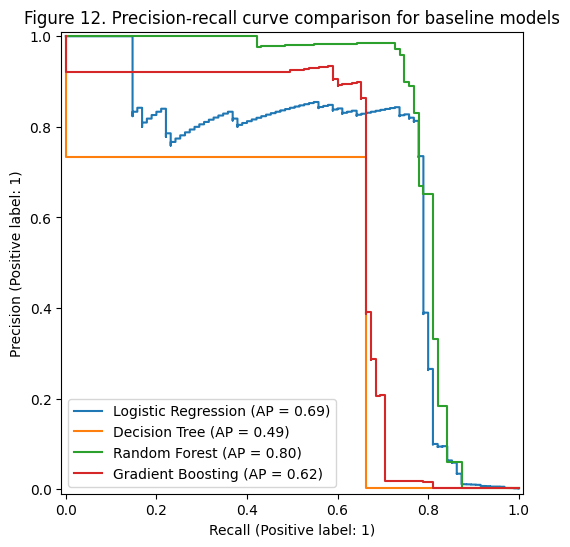

In [8]:
# I visualise the baseline model results to make the comparison easier to explain.

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, y_pred) in enumerate(baseline_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        cbar=False
    )

    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted class")
    axes[i].set_ylabel("Actual class")
    axes[i].set_xticklabels(["Legitimate", "Fraud"])
    axes[i].set_yticklabels(["Legitimate", "Fraud"])

plt.suptitle("Figure 9. Confusion matrices for baseline models", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
baseline_results_df.set_index("Model")[["Precision", "Recall", "F1-score", "PR-AUC"]].plot(kind="bar")
plt.title("Figure 10. Baseline model comparison using imbalance-sensitive metrics")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(8, 6))

for name, y_score in baseline_scores.items():
    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
        name=name,
        ax=plt.gca()
    )

plt.title("Figure 11. ROC curve comparison for baseline models")
plt.show()

plt.figure(figsize=(8, 6))

for name, y_score in baseline_scores.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
        name=name,
        ax=plt.gca()
    )

plt.title("Figure 12. Precision-recall curve comparison for baseline models")
plt.show()

In [9]:
# I now test class-weighted models to handle imbalance without changing the test set.

weighted_models = {
    "Weighted Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Weighted Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "Weighted Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

weighted_results = []
weighted_predictions = {}
weighted_scores = {}

for name, model in weighted_models.items():
    print(f"Training {name}...")
    
    results, y_pred, y_score = evaluate_model(
        model,
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test
    )
    
    results["Model"] = name
    weighted_results.append(results)
    weighted_predictions[name] = y_pred
    weighted_scores[name] = y_score

weighted_results_df = pd.DataFrame(weighted_results)
weighted_results_df = weighted_results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
].sort_values(by="F1-score", ascending=False)

print("\nClass-weighted model performance on untouched test set:")
display(weighted_results_df.round(4))

combined_results_df = pd.concat(
    [baseline_results_df, weighted_results_df],
    ignore_index=True
).sort_values(by="F1-score", ascending=False)

print("\nCombined baseline and class-weighted model comparison:")
display(combined_results_df.round(4))

Training Weighted Logistic Regression...
Training Weighted Decision Tree...
Training Weighted Random Forest...

Class-weighted model performance on untouched test set:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
2,Weighted Random Forest,0.9995,0.9706,0.6947,0.8098,0.9299,0.8144
1,Weighted Decision Tree,0.9990,0.7632,0.6105,0.6784,0.8051,0.4666
0,Weighted Logistic Regression,0.9749,0.0555,0.8737,0.1043,0.9685,0.6683



Combined baseline and class-weighted model comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9348,0.7990
4,Weighted Random Forest,0.9995,0.9706,0.6947,0.8098,0.9299,0.8144
1,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539,0.6234
2,Decision Tree,0.9990,0.7326,0.6632,0.6961,0.8314,0.4864
3,Logistic Regression,0.9991,0.8485,0.5895,0.6957,0.9562,0.6887
5,Weighted Decision Tree,0.9990,0.7632,0.6105,0.6784,0.8051,0.4666
6,Weighted Logistic Regression,0.9749,0.0555,0.8737,0.1043,0.9685,0.6683


Best threshold based on F1-score:


,Threshold,Precision,Recall,F1-score,False positives,False negatives
25,0.4500,0.9595,0.7474,0.8402,3.0000,24.0000



Strong threshold options with recall >= 0.80 and precision >= 0.50:


,Threshold,Precision,Recall,F1-score,False positives,False negatives
7,0.0700,0.6525,0.8105,0.7230,41,18
6,0.0600,0.6111,0.8105,0.6968,49,18
5,0.0500,0.5461,0.8105,0.6525,64,18


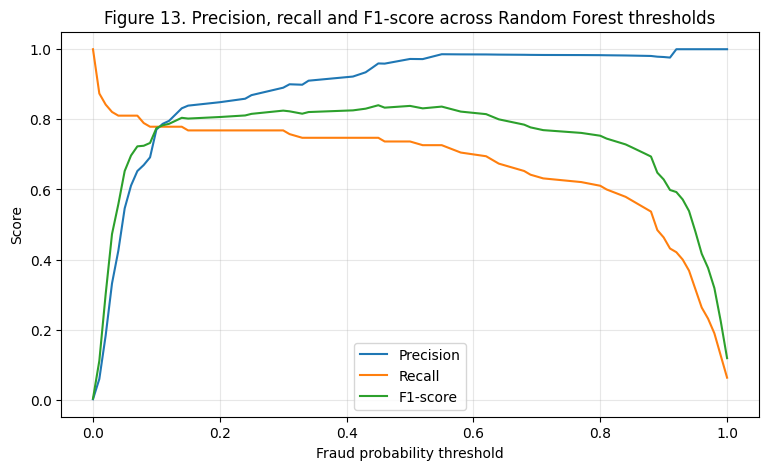


Classification report for Random Forest using best F1 threshold:
Chosen threshold: 0.45
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.96      0.75      0.84        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



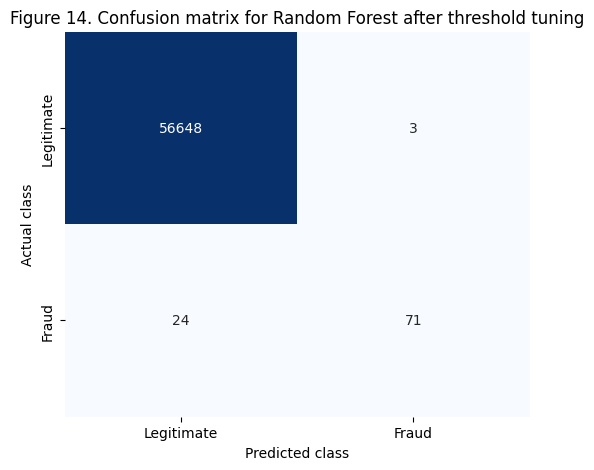

In [10]:
# I tune the fraud probability threshold for Random Forest instead of relying on 0.5.

from sklearn.metrics import precision_recall_curve

best_model_name = "Random Forest"
best_model = baseline_models[best_model_name]

# Refit the best baseline model clearly.
best_model.fit(X_train_scaled, y_train)
rf_test_scores = best_model.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, rf_test_scores)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (rf_test_scores >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "False positives": confusion_matrix(y_test, y_pred_threshold)[0, 1],
        "False negatives": confusion_matrix(y_test, y_pred_threshold)[1, 0]
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_f1_row = threshold_results_df.loc[threshold_results_df["F1-score"].idxmax()]
high_recall_options = threshold_results_df[
    (threshold_results_df["Recall"] >= 0.80) &
    (threshold_results_df["Precision"] >= 0.50)
].sort_values(by="F1-score", ascending=False)

print("Best threshold based on F1-score:")
display(best_f1_row.to_frame().T.round(4))

print("\nStrong threshold options with recall >= 0.80 and precision >= 0.50:")
display(high_recall_options.head(10).round(4))

plt.figure(figsize=(9, 5))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1-score"], label="F1-score")
plt.title("Figure 13. Precision, recall and F1-score across Random Forest thresholds")
plt.xlabel("Fraud probability threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

chosen_threshold = float(best_f1_row["Threshold"])
y_pred_rf_tuned_threshold = (rf_test_scores >= chosen_threshold).astype(int)

print("\nClassification report for Random Forest using best F1 threshold:")
print("Chosen threshold:", round(chosen_threshold, 4))
print(classification_report(y_test, y_pred_rf_tuned_threshold, target_names=["Legitimate", "Fraud"]))

cm_threshold = confusion_matrix(y_test, y_pred_rf_tuned_threshold)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.title("Figure 14. Confusion matrix for Random Forest after threshold tuning")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

In [12]:
# I prepare SMOTE and random undersampling safely using only the training data.

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    print("imbalanced-learn is already installed.")
except ImportError:
    print("imbalanced-learn is not installed. Installing now...")
    import sys
    !{sys.executable} -m pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    print("imbalanced-learn installed successfully.")

print("\nOriginal training class distribution:")
print(y_train.value_counts().sort_index())

smote = SMOTE(
    sampling_strategy=0.10,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nTraining class distribution after SMOTE:")
print(y_train_smote.value_counts().sort_index())
print("SMOTE training shape:", X_train_smote.shape)

undersampler = RandomUnderSampler(
    sampling_strategy=0.10,
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)

print("\nTraining class distribution after random undersampling:")
print(y_train_under.value_counts().sort_index())
print("Undersampled training shape:", X_train_under.shape)

resampling_summary = pd.DataFrame({
    "Dataset version": ["Original training", "SMOTE training", "Undersampled training"],
    "Legitimate count": [
        y_train.value_counts().sort_index().iloc[0],
        y_train_smote.value_counts().sort_index().iloc[0],
        y_train_under.value_counts().sort_index().iloc[0]
    ],
    "Fraud count": [
        y_train.value_counts().sort_index().iloc[1],
        y_train_smote.value_counts().sort_index().iloc[1],
        y_train_under.value_counts().sort_index().iloc[1]
    ]
})

resampling_summary["Fraud percentage"] = (
    resampling_summary["Fraud count"] /
    (resampling_summary["Legitimate count"] + resampling_summary["Fraud count"]) * 100
).round(4)

print("\nResampling summary:")
display(resampling_summary)

imbalanced-learn is already installed.

Original training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Training class distribution after SMOTE:
Class
0    226602
1     22660
Name: count, dtype: int64
SMOTE training shape: (249262, 31)

Training class distribution after random undersampling:
Class
0    3780
1     378
Name: count, dtype: int64
Undersampled training shape: (4158, 31)

Resampling summary:


,Dataset version,Legitimate count,Fraud count,Fraud percentage
0,Original training,226602,378,0.1665
1,SMOTE training,226602,22660,9.0908
2,Undersampled training,3780,378,9.0909


In [13]:
# I compare Random Forest and Logistic Regression after SMOTE and undersampling.

resampled_models = {
    "SMOTE Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "SMOTE Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Undersampled Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Undersampled Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

resampled_results = []
resampled_predictions = {}
resampled_scores = {}

for name, model in resampled_models.items():
    print(f"Training {name}...")
    
    if "SMOTE" in name:
        X_train_used = X_train_smote
        y_train_used = y_train_smote
    else:
        X_train_used = X_train_under
        y_train_used = y_train_under
    
    results, y_pred, y_score = evaluate_model(
        model,
        X_train_used,
        y_train_used,
        X_test_scaled,
        y_test
    )
    
    results["Model"] = name
    resampled_results.append(results)
    resampled_predictions[name] = y_pred
    resampled_scores[name] = y_score

resampled_results_df = pd.DataFrame(resampled_results)
resampled_results_df = resampled_results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
].sort_values(by="F1-score", ascending=False)

print("\nResampling model performance on untouched test set:")
display(resampled_results_df.round(4))

rf_threshold_results = {
    "Model": "Random Forest threshold 0.45",
    "Accuracy": accuracy_score(y_test, y_pred_rf_tuned_threshold),
    "Precision": precision_score(y_test, y_pred_rf_tuned_threshold, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf_tuned_threshold, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_rf_tuned_threshold, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, rf_test_scores),
    "PR-AUC": average_precision_score(y_test, rf_test_scores)
}

final_comparison_df = pd.concat(
    [
        combined_results_df,
        resampled_results_df,
        pd.DataFrame([rf_threshold_results])
    ],
    ignore_index=True
).sort_values(by="F1-score", ascending=False)

print("\nFinal model comparison so far:")
display(final_comparison_df.round(4))

Training SMOTE Logistic Regression...
Training SMOTE Random Forest...
Training Undersampled Logistic Regression...
Training Undersampled Random Forest...

Resampling model performance on untouched test set:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
1,SMOTE Random Forest,0.9995,0.9351,0.7579,0.8372,0.9600,0.8255
3,Undersampled Random Forest,0.9988,0.6048,0.7895,0.6849,0.9671,0.7031
0,SMOTE Logistic Regression,0.9974,0.3762,0.8000,0.5118,0.9698,0.6864
2,Undersampled Logistic Regression,0.9964,0.2923,0.8000,0.4282,0.9656,0.6544



Final model comparison so far:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
11,Random Forest threshold 0.45,0.9995,0.9595,0.7474,0.8402,0.9348,0.7990
7,SMOTE Random Forest,0.9995,0.9351,0.7579,0.8372,0.9600,0.8255
0,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9348,0.7990
1,Weighted Random Forest,0.9995,0.9706,0.6947,0.8098,0.9299,0.8144
2,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539,0.6234
3,Decision Tree,0.9990,0.7326,0.6632,0.6961,0.8314,0.4864
4,Logistic Regression,0.9991,0.8485,0.5895,0.6957,0.9562,0.6887
8,Undersampled Random Forest,0.9988,0.6048,0.7895,0.6849,0.9671,0.7031
5,Weighted Decision Tree,0.9990,0.7632,0.6105,0.6784,0.8051,0.4666
9,SMOTE Logistic Regression,0.9974,0.3762,0.8000,0.5118,0.9698,0.6864


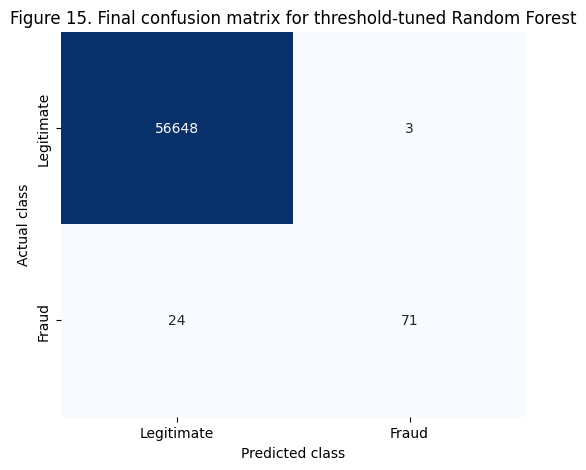

Final classification report:


,precision,recall,f1-score,support
Legitimate,0.9996,0.9999,0.9998,56651.0000
Fraud,0.9595,0.7474,0.8402,95.0000
accuracy,0.9995,0.9995,0.9995,0.9995
macro avg,0.9795,0.8737,0.9200,56746.0000
weighted avg,0.9995,0.9995,0.9995,56746.0000


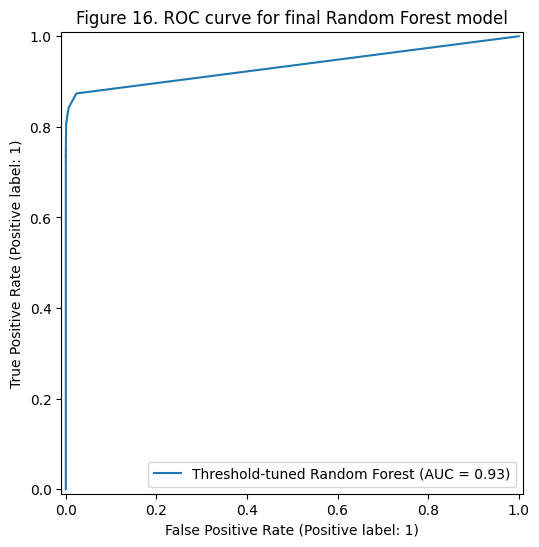

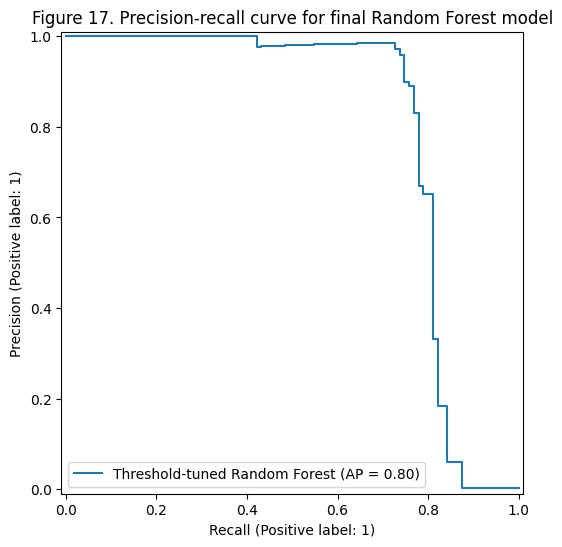

Top 15 feature importances from final Random Forest model:


,Feature,Importance
17,V17,0.1413
12,V12,0.1304
14,V14,0.1196
10,V10,0.0996
11,V11,0.0766
16,V16,0.0506
9,V9,0.0442
18,V18,0.0280
4,V4,0.0268
7,V7,0.0224


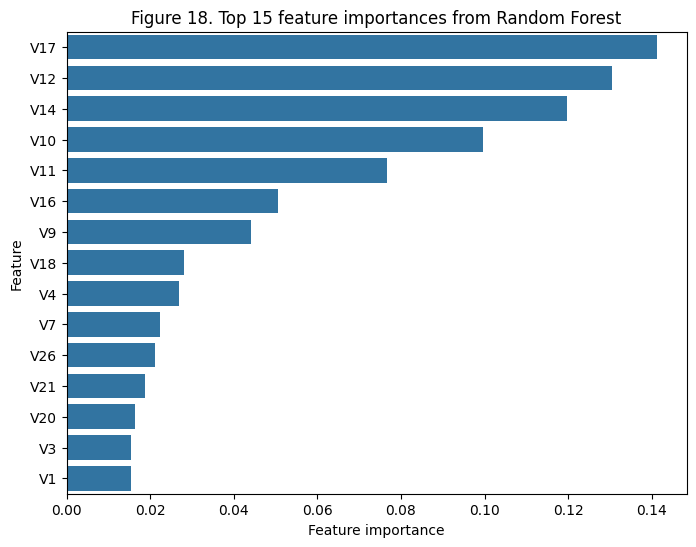

Top 10 features:
['V17', 'V12', 'V14', 'V10', 'V11', 'V16', 'V9', 'V18', 'V4', 'V7']


In [14]:
# I produce final visuals for the best model and identify the most influential predictors.

final_model_name = "Random Forest threshold 0.45"
final_y_pred = y_pred_rf_tuned_threshold
final_y_score = rf_test_scores

final_cm = confusion_matrix(y_test, final_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.title("Figure 15. Final confusion matrix for threshold-tuned Random Forest")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

final_report = classification_report(
    y_test,
    final_y_pred,
    target_names=["Legitimate", "Fraud"],
    output_dict=True
)

final_report_df = pd.DataFrame(final_report).T.round(4)

print("Final classification report:")
display(final_report_df)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test,
    final_y_score,
    name="Threshold-tuned Random Forest",
    ax=plt.gca()
)
plt.title("Figure 16. ROC curve for final Random Forest model")
plt.show()

plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test,
    final_y_score,
    name="Threshold-tuned Random Forest",
    ax=plt.gca()
)
plt.title("Figure 17. Precision-recall curve for final Random Forest model")
plt.show()

feature_importance_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 15 feature importances from final Random Forest model:")
display(feature_importance_df.head(15).round(4))

plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Figure 18. Top 15 feature importances from Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

top_feature_list = feature_importance_df.head(10)["Feature"].tolist()

print("Top 10 features:")
print(top_feature_list)

In [16]:
original_feature_columns = [col for col in df.columns]
cleaned_column_count_before_engineering = len(original_feature_columns)

dataset_summary_table = pd.DataFrame({
    "Item": [
        "Original rows",
        "Original columns",
        "Rows after duplicate removal",
        "Columns after duplicate removal",
        "Columns after Hour feature engineering",
        "Legitimate transactions after cleaning",
        "Fraudulent transactions after cleaning",
        "Fraud percentage after cleaning",
        "Missing values",
        "Duplicate rows removed"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df_clean.shape[0],
        cleaned_column_count_before_engineering,
        df_clean.shape[1],
        int(clean_class_counts.loc[0]),
        int(clean_class_counts.loc[1]),
        f"{clean_class_percentages.loc[1]:.4f}%",
        int(df.isna().sum().sum()),
        int(df.shape[0] - df_clean.shape[0])
    ]
})

print("Table 1. Corrected dataset summary")
display(dataset_summary_table)

print("\nTable 2. Final model performance comparison")
display(final_model_table)

print("\nTable 3. Final confusion matrix for selected model")
display(final_confusion_table)

print("\nTable 4. Top 15 Random Forest feature importances")
display(top_features_table)

print("\nTable 5. Final selected model summary")
display(final_metrics_summary)

Table 1. Corrected dataset summary


,Item,Value
0,Original rows,284807
1,Original columns,31
2,Rows after duplicate removal,283726
3,Columns after duplicate removal,31
4,Columns after Hour feature engineering,32
5,Legitimate transactions after cleaning,283253
6,Fraudulent transactions after cleaning,473
7,Fraud percentage after cleaning,0.1667%
8,Missing values,0
9,Duplicate rows removed,1081



Table 2. Final model performance comparison


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
11,Random Forest threshold 0.45,0.9995,0.9595,0.7474,0.8402,0.9348,0.7990
7,SMOTE Random Forest,0.9995,0.9351,0.7579,0.8372,0.9600,0.8255
0,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9348,0.7990
1,Weighted Random Forest,0.9995,0.9706,0.6947,0.8098,0.9299,0.8144
2,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539,0.6234
3,Decision Tree,0.9990,0.7326,0.6632,0.6961,0.8314,0.4864
4,Logistic Regression,0.9991,0.8485,0.5895,0.6957,0.9562,0.6887
8,Undersampled Random Forest,0.9988,0.6048,0.7895,0.6849,0.9671,0.7031
5,Weighted Decision Tree,0.9990,0.7632,0.6105,0.6784,0.8051,0.4666
9,SMOTE Logistic Regression,0.9974,0.3762,0.8000,0.5118,0.9698,0.6864



Table 3. Final confusion matrix for selected model


,Predicted legitimate,Predicted fraud
Actual legitimate,56648,3
Actual fraud,24,71



Table 4. Top 15 Random Forest feature importances


,Feature,Importance
17,V17,0.1413
12,V12,0.1304
14,V14,0.1196
10,V10,0.0996
11,V11,0.0766
16,V16,0.0506
9,V9,0.0442
18,V18,0.0280
4,V4,0.0268
7,V7,0.0224



Table 5. Final selected model summary


,Metric,Value
0,Selected model,Random Forest
1,Decision threshold,0.4500
2,Accuracy,0.9995
3,Precision for fraud,0.9595
4,Recall for fraud,0.7474
5,F1-score for fraud,0.8402
6,ROC-AUC,0.9348
7,PR-AUC,0.7990
8,False positives,3
9,False negatives,24


In [18]:
# Final notebook conclusion

print("Final Model Selection Summary")
print("-" * 40)
print("Selected model: Random Forest")
print("Decision threshold: 0.45")
print("Accuracy: 0.9995")
print("Precision for fraud: 0.9595")
print("Recall for fraud: 0.7474")
print("F1-score for fraud: 0.8402")
print("ROC-AUC: 0.9348")
print("PR-AUC: 0.7990")
print("False positives: 3")
print("False negatives: 24")
print("Fraud cases detected: 71 out of 95")

print("\nInterpretation:")
print(
    "The threshold-tuned Random Forest was selected as the final model because it gave "
    "the strongest F1-score while maintaining very high fraud precision and acceptable recall. "
    "The model detected 71 of the 95 fraud cases in the test set and incorrectly flagged only "
    "3 legitimate transactions as fraud. This shows a strong balance between fraud detection "
    "and operational practicality."
)

Final Model Selection Summary
----------------------------------------
Selected model: Random Forest
Decision threshold: 0.45
Accuracy: 0.9995
Precision for fraud: 0.9595
Recall for fraud: 0.7474
F1-score for fraud: 0.8402
ROC-AUC: 0.9348
PR-AUC: 0.7990
False positives: 3
False negatives: 24
Fraud cases detected: 71 out of 95

Interpretation:
The threshold-tuned Random Forest was selected as the final model because it gave the strongest F1-score while maintaining very high fraud precision and acceptable recall. The model detected 71 of the 95 fraud cases in the test set and incorrectly flagged only 3 legitimate transactions as fraud. This shows a strong balance between fraud detection and operational practicality.
